In [ ]:
import numpy as np
import math
from scipy.stats import sem
import matplotlib.pyplot as plt
import pandas as pd
import time
import pprint
import seaborn as sns
import statsmodels.formula.api as smf
import CMR_IA as cmr
import scipy as sp
import json
import statsmodels.formula.api as smf
from scipy import stats

from CMR_IA.utils import wmse

cmr.analysis.setup_notebook()

SAVEFIG = False
SAVERES = False

## Load Stimuli and Semantic Matrix

In [2]:
# Load study and test data
df_study = pd.read_parquet("data/simu4_study.parquet")
df_test = pd.read_parquet("data/simu4_test.parquet")

In [3]:
# Inspect study data
df_study

,itemno1,item,itemno_old,freq,quantile,session,list,itemno2
0,316,FARM,552,1161,8,0,0,-1
1,477,LEOPARD,812,118,3,0,0,-1
2,433,INSTRUCTOR,741,78,2,0,0,-1
3,87,BOTTLE,153,1479,8,0,0,-1
4,84,BOOT,150,149,3,0,0,-1
...,...,...,...,...,...,...,...,...
99995,895,TOWN,1491,3328,9,999,0,-1
99996,633,PIANO,1057,466,6,999,0,-1
99997,843,SUBMARINE,1398,154,3,999,0,-1
99998,462,LABYRINTH,791,32,0,999,0,-1


In [4]:
# Inspect test data
df_test

,itemno1,item,itemno_old,freq,quantile,session,list,position,old,itemno2
0,341,FORT,595,411,6,0,0,0,True,-1
1,512,MANSION,864,156,3,0,0,1,True,-1
2,66,BENCH,121,345,6,0,0,2,True,-1
3,386,GUARD,667,658,7,0,0,3,False,-1
4,57,BEE,112,185,4,0,0,4,True,-1
...,...,...,...,...,...,...,...,...,...,...
199995,503,LUNG,850,169,4,999,0,195,True,-1
199996,891,TORNADO,1485,34,0,999,0,196,False,-1
199997,932,VEHICLE,1553,383,6,999,0,197,False,-1
199998,735,RUG,1215,321,5,999,0,198,True,-1


In [5]:
# Load semantic matrix
sem_mat = np.load("data/simu4_smat.npy")

In [6]:
# Get word frequency quantile data
df = pd.read_parquet("data/simu4_word_freq.parquet")
df

,item,itemno_old,itemno,freq,quantile
0,ABDOMEN,1,1,110,2
1,ACROBAT,4,2,17,0
2,ADULT,8,3,906,8
3,ALLEY,15,4,165,4
4,ALLIGATOR,16,5,12,0
...,...,...,...,...,...
979,YOKE,1632,980,12,0
980,YOLK,1633,981,47,1
981,YOUTH,1634,982,1159,8
982,ZIPPER,1636,983,24,0


In [7]:
# Check mean frequency of each group
freq_mean = df.groupby("quantile").freq.mean().to_numpy()
freq_mean = np.around(freq_mean, decimals=0)
freq_mean

array([  21.,   51.,   90.,  141.,  196.,  284.,  415.,  632., 1163.,
       4332.])

In [8]:
# Load ground truth
with open("data/simu4_gt.json") as f:
    gt = json.load(f)
hr_gt = np.array(gt["hr"])
hr_std_gt = np.array(gt["hr_std"])
far_gt = np.array(gt["far"])
far_std_gt = np.array(gt["far_std"])
hr_gt, far_gt

(array([0.90287356, 0.88502554, 0.88761973, 0.88043582, 0.87863985,
        0.87963761, 0.86965996, 0.86187739, 0.84172254, 0.83693327]),
 array([0.11368631, 0.13186813, 0.14265734, 0.16373626, 0.17142857,
        0.18301698, 0.18661339, 0.19320679, 0.19150849, 0.19280719]))


========== Start control experiment: base ==========


100%|██████████| 1000/1000 [01:08<00:00, 14.51it/s]


CMR Time: 69.11970376968384


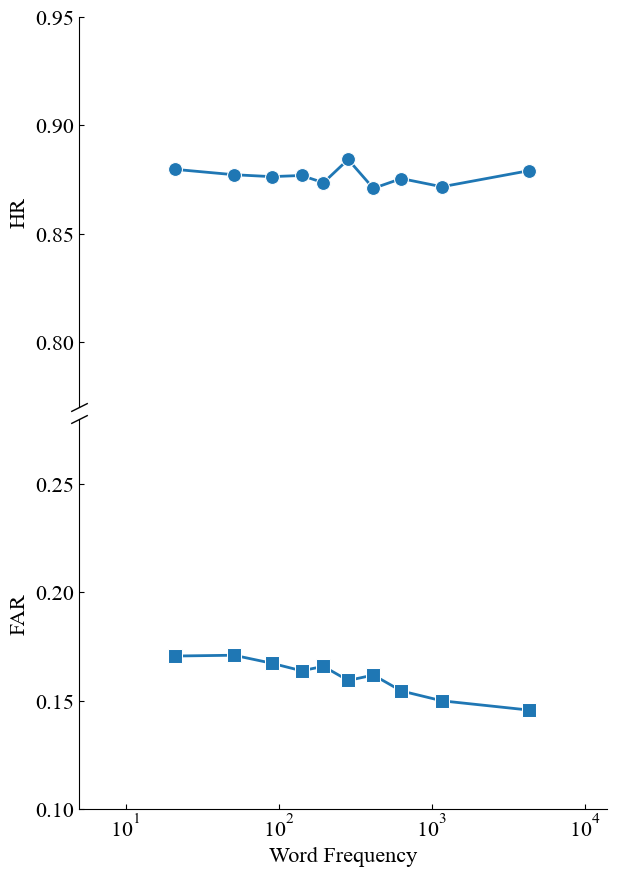

Error: 247.5652573363871
HR slope: mean -0.000513937117686531, sem 0.0007713225097061361, T -0.6663063909315111, p 0.5053691181227767
FAR slope: mean -0.005313942042400746, sem 0.0008232202161563476, T -6.455067475397752, p 1.684610237007367e-10

========== Start control experiment: attn ==========


100%|██████████| 1000/1000 [01:30<00:00, 11.08it/s]


CMR Time: 90.41653609275818


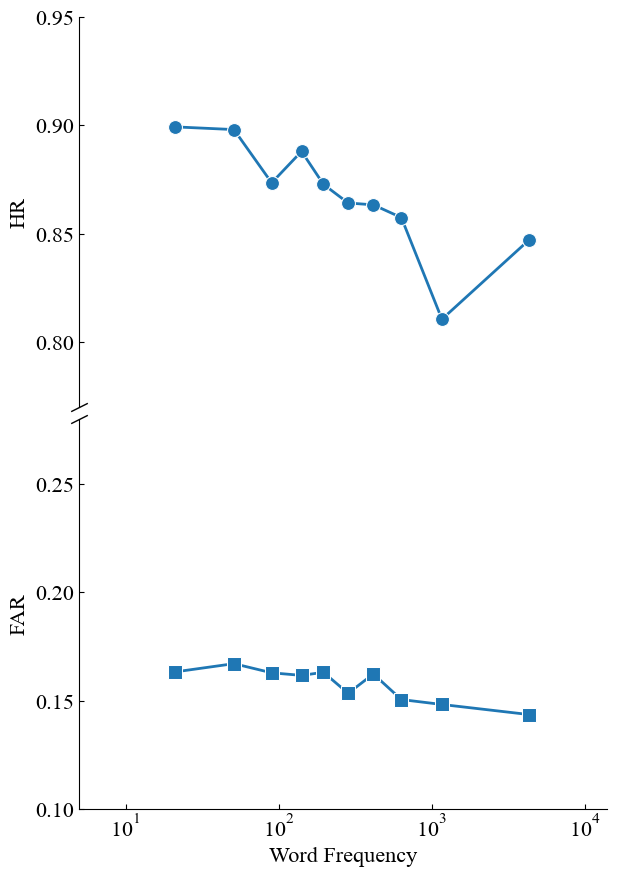

Error: 210.65989363674987
HR slope: mean -0.01397186049443971, sem 0.0007859907655369174, T -17.776112782820555, p 1.2344654972337497e-61
FAR slope: mean -0.004474499074870829, sem 0.0008228470471336619, T -5.4378260096545, p 6.781279011135003e-08

========== Start control experiment: shift ==========


100%|██████████| 1000/1000 [00:57<00:00, 17.44it/s]


CMR Time: 57.5129132270813


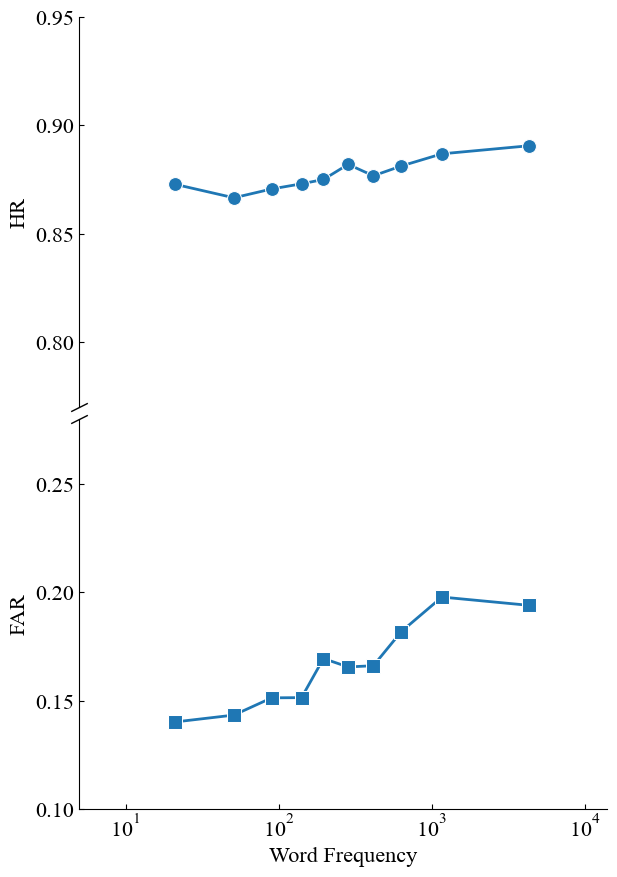

Error: 123.88282886197428
HR slope: mean 0.004351228277501033, sem 0.0007512584594956284, T 5.791919175755189, p 9.316346769752778e-09
FAR slope: mean 0.012239804951532903, sem 0.00084332604554706, T 14.513728131796313, p 1.880597424691918e-43


In [9]:
for which in ["base", "attn", "shift"]:
    print(f"\n========== Start control experiment: {which} ==========")

    # Define parameters and load PSO results
    params = cmr.load_params(f"4{which}")

    # Run model or load saved results
    if SAVERES:
        df_simu = cmr.run_norm_recog_multi_sess(params, df_study, df_test, sem_mat)
        df_simu = df_simu.merge(df_test, on=["session", "list", "itemno1", "itemno2"])
        df_simu.to_parquet(f"data/simu4_result_{which}.parquet")
    else:
        df_simu = pd.read_parquet(f"data/simu4_result_{which}.parquet")

    # Session-wise, get yes rate for each condition
    df_sess_q = df_simu.groupby(["session", "quantile", "old"]).s_resp.mean().to_frame(name="yes_rate").reset_index()

    # Collapse across session
    df_q = df_sess_q.groupby(["quantile", "old"]).yes_rate.mean().to_frame().reset_index()

    # Format df for plotting
    df_plot = pd.pivot_table(df_q, values="yes_rate", index="quantile", columns="old").reset_index()
    df_plot.rename(columns={False: "far", True: "hr"}, inplace=True)
    df_plot["freq_mean"] = freq_mean

    # Plot HR and FAR by word frequency
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 9))
    fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)
    fig.subplots_adjust(hspace=0.03)

    sns.lineplot(data=df_plot, y="hr", x="freq_mean", ax=ax1, marker="o", color="C0", markersize=10, linewidth=2)
    sns.lineplot(data=df_plot, y="far", x="freq_mean", ax=ax2, marker="s", color="C0", markersize=10, linewidth=2)

    ax1.set_ylim(0.77, 0.95)
    ax1.set_yticks(np.arange(0.80, 0.96, 0.05))
    ax2.set_ylim(0.1, 0.28)
    ax2.set_yticks(np.arange(0.1, 0.30, 0.05))
    ax1.tick_params(axis="y", direction="in")
    ax1.tick_params(axis="x", direction="in")
    ax2.tick_params(axis="y", direction="in")
    ax2.tick_params(axis="x", direction="in")
    plt.xscale("log")
    plt.xlim(5, 14000)

    ax1.spines.bottom.set_visible(False)
    ax1.spines.top.set_visible(False)
    ax2.spines.top.set_visible(False)
    ax1.spines.right.set_visible(False)
    ax2.spines.right.set_visible(False)
    ax1.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False, labeltop=False)
    ax2.minorticks_off()

    d = 0.5  # proportion of vertical to horizontal extent of the slanted line
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12, linestyle="none", color="k", mec="k", mew=1, clip_on=False)
    ax1.plot(0, 0, transform=ax1.transAxes, **kwargs)
    ax2.plot(0, 1, transform=ax2.transAxes, **kwargs)

    ax1.set_ylabel("HR")
    ax2.set_ylabel("FAR")
    ax2.set_xlabel("Word Frequency")

    if SAVEFIG:
        ax1.set_ylabel(None)
        ax1.set_xlabel(None)
        ax2.set_ylabel(None)
        ax2.set_xlabel(None)
        ax1.tick_params(labelleft=False)
        ax2.tick_params(labelleft=False)
        plt.savefig(f"figures/simu4_WFE_{which}.pdf")
    plt.show()

    # Error check
    hr = df_q.query("old == True")["yes_rate"].to_numpy()
    far = df_q.query("old == False")["yes_rate"].to_numpy()
    err = wmse(hr_gt, hr, hr_std_gt) + wmse(far_gt, far, far_std_gt)
    print(f"Error: {err}")

    # Slope check
    # Add log frequency to session-wise data
    sessions = df_sess_q.session.unique()
    df_sess_q["freq_mean"] = df_sess_q["quantile"].apply(lambda x: freq_mean[x])
    df_sess_q["log_freq_mean"] = np.log(df_sess_q["freq_mean"])

    # Fit OLS slopes per session for HR and FAR
    slopes_hr, slopes_far = [], []
    for sess in sessions:
        # slope for HR
        df_tmp = df_sess_q.query("session == @sess and old == True").copy()
        res = smf.ols(formula="yes_rate ~ log_freq_mean", data=df_tmp).fit()
        slopes_hr.append(res.params["log_freq_mean"])

        # slope for FAR
        df_tmp = df_sess_q.query("session == @sess and old == False").copy()
        res = smf.ols(formula="yes_rate ~ log_freq_mean", data=df_tmp).fit()
        slopes_far.append(res.params["log_freq_mean"])

    # T test
    t_stat_hr, p_val_hr = stats.ttest_1samp(slopes_hr, 0)
    t_stat_far, p_val_far = stats.ttest_1samp(slopes_far, 0)
    print(f"HR slope: mean {np.mean(slopes_hr)}, sem {sem(slopes_hr)}, T {t_stat_hr}, p {p_val_hr}")
    print(f"FAR slope: mean {np.mean(slopes_far)}, sem {sem(slopes_far)}, T {t_stat_far}, p {p_val_far}")